# Adaptive Agent Analysis

Comprehensive analysis of the Neural LSTM-based Adaptive Agent performance:
- Inference time and computational efficiency
- Win rates against all opponents (with confidence intervals)
- Adversary identification speed and accuracy
- Performance breakdown by player position and opponent type

## 1. Import Required Libraries

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Tuple
from scipy import stats
import time

# Setup paths
sys.path.insert(0, str(Path().cwd().parent))

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Agent and Setup Game Environment

In [2]:
import importlib
import sys

# Reload modules to pick up code changes
modules_to_reload = [
    'liars_dice.agents.adapter_agent.adaptive_training',
    'liars_dice.agents.adapter_agent',
    'liars_dice.agents.adapter_agent.action_tracker',
    'liars_dice.agents.adaptive_agent',
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from liars_dice.core.config import GameConfig
from liars_dice.core.engine import GameEngine
from liars_dice.agents.adaptive_agent import AdaptiveAgent
from liars_dice.agents.ppo_agent import PPOAgent
from liars_dice.agents import AGENT_MAP
from liars_dice.agents.adaptive_agent_utils.config import PATH_CONFIG
from liars_dice.agents.adaptive_agent_utils.action_tracker import ActionTrackerWrapper

print("="*60)
print("AVAILABLE AGENTS IN AGENT_MAP")
print("="*60)
print(f"Total agents in AGENT_MAP: {len(AGENT_MAP)}")
print(f"Agent keys: {sorted(AGENT_MAP.keys())}\n")

# Build opponent classes (match train_adaptive_agent.py logic)
opponent_classes = {}
for agent_name, agent_cls in AGENT_MAP.items():
    if agent_name not in ["rl_ppo", "adaptive"]:  # Exclude base RL and adaptive
        try:
            _ = agent_cls()
            opponent_classes[agent_cls.__name__] = agent_cls
        except Exception:
            pass

# Add the frozen generalist PPO as an opponent
class GeneralistPPOAgent(PPOAgent):
    """Frozen generalist PPO model as a trainable opponent."""
    def __init__(self):
        super().__init__(model_path=PATH_CONFIG["generalist_model"], stochastic=False)

opponent_classes["GeneralistPPO"] = GeneralistPPOAgent

print("="*60)
print("OPPONENT CLASSES FOR ANALYSIS")
print("="*60)
print(f"Total opponent classes: {len(opponent_classes)}")
print(f"Opponents: {sorted(opponent_classes.keys())}\n")

# Verify all trainable agents are included (compare by class name)
available_class_names = {cls.__name__ for key, cls in AGENT_MAP.items() if key not in ["rl_ppo", "adaptive"]}
missing = available_class_names - set(opponent_classes.keys())
if missing:
    print(f"⚠️  Warning: These agent classes are not in opponent_classes: {sorted(missing)}")
else:
    print("✓ All available agents are included in opponent_classes")

# Initialize adaptive agent
try:
    adaptive_agent = AdaptiveAgent(device="cpu")
    print(f"\n✓ Adaptive Agent loaded successfully")
except Exception as e:
    print(f"Error loading Adaptive Agent: {e}")

AVAILABLE AGENTS IN AGENT_MAP
Total agents in AGENT_MAP: 30
Agent keys: ['adaptive', 'aggressive', 'alternator', 'bayesian', 'bluffing', 'chaotic', 'chaotic_safe', 'chaotic_unsafe', 'conservative', 'cycleface', 'hat_adapter_agent', 'maxcount', 'maxraise', 'minraise', 'mirror', 'nash_cfr', 'onesarewild', 'parity', 'probability_maxraise', 'probability_minraise', 'random', 'random_aggressive', 'random_cautious', 'random_facefixed', 'random_facerandom', 'randomface', 'randomthreshold', 'rl_ppo', 'safeface', 'thresholdliar']

OPPONENT CLASSES FOR ANALYSIS
Total opponent classes: 29
Opponents: ['AggressiveAgent', 'AggressiveRandomAgent', 'AlternatorAgent', 'BayesianAgent', 'BluffingAgent', 'CautiousRandomAgent', 'ChaoticAgent', 'ChaoticSafeAgent', 'ChaoticUnsafeAgent', 'ConservativeAgent', 'CycleFaceAgent', 'FaceFixedRandomAgent', 'FaceRandomRandomAgent', 'GeneralistPPO', 'HatAdapterAgent', 'MaxCountBidAgent', 'MaxRaiseAgent', 'MinRaiseAgent', 'MirrorAgent', 'NashCFRAgent', 'OnesAreWildAgent

## 3. Game Metrics Collection Functions

In [3]:
class AdaptiveAgentMetrics:
    """Collects metrics during adaptive agent gameplay."""
    
    def __init__(self):
        self.inference_times = []  # Time per action selection
        self.steps_to_identification = None  # When was opponent identified
        self.predicted_opponent = None  # Predicted opponent (highest confidence)
        self.actual_opponent = None  # Ground truth opponent
        self.identification_correct = None  # Was prediction correct
        self.belief_trajectory = []  # Belief distribution over time
        self.won = None  # Did adaptive agent win
        self.was_player_0 = None  # Was adaptive agent player 0

def play_game_with_metrics(
    adaptive_agent: AdaptiveAgent,
    opponent_cls,
    opponent_name: str,
    game_config: GameConfig,
    adaptive_is_player_0: bool = True
) -> Tuple[AdaptiveAgentMetrics, bool]:
    """
    Play a game and collect metrics from the adaptive agent.
    IMPORTANT: Uses ActionTrackerWrapper to properly capture opponent actions for belief updating.
    
    Returns:
        metrics: AdaptiveAgentMetrics object
        adaptive_won: Whether adaptive agent won
    """    
    metrics = AdaptiveAgentMetrics()
    metrics.actual_opponent = opponent_name
    metrics.was_player_0 = adaptive_is_player_0
    
    # Setup agents
    opponent = opponent_cls()
    adaptive_agent.reset()
    
    # Wrap opponent to track its actions
    wrapped_opponent = ActionTrackerWrapper(opponent, adaptive_agent=adaptive_agent)
    
    if adaptive_is_player_0:
        agents = [adaptive_agent, wrapped_opponent]
        adaptive_player = 0
    else:
        agents = [wrapped_opponent, adaptive_agent]
        adaptive_player = 1
    
    # Play match with dice elimination
    engine = GameEngine(game_config)
    dice_counts = [game_config.total_dice, game_config.total_dice]
    
    steps = 0
    identified_at_step = None
    
    while min(dice_counts) > 0:
        # Update dice counts
        for i in range(2):
            engine.state.players[i].num_dice = dice_counts[i]
        engine.start_new_round()
        
        # Play round
        while not engine.is_terminal():
            current_player = engine.state.public.current_player
            view = engine.get_view(current_player)
            
            # Measure inference time for adaptive agent
            if current_player == adaptive_player:
                start_time = time.time()
                action = agents[current_player].choose_action(view)
                inference_time = time.time() - start_time
                metrics.inference_times.append(inference_time)
                steps += 1
            else:
                # Opponent turn - action will be tracked via ActionTrackerWrapper
                action = agents[current_player].choose_action(view)
            
            try:
                engine.apply_action(current_player, action)
            except Exception:
                break
            
            # Check identification status AFTER each action (both players)
            # This ensures we capture when beliefs update from opponent actions
            if identified_at_step is None:
                belief_summary = adaptive_agent.get_belief_summary()
                if not belief_summary['using_generalist']:
                    identified_at_step = steps
                metrics.belief_trajectory.append(belief_summary['beliefs'].copy())
        
        # Round ended
        if engine.is_terminal():
            round_loser = engine.state.public.loser
            dice_counts[round_loser] -= 1
    
    # Determine winner
    winner = 0 if dice_counts[0] > 0 else 1
    metrics.won = (winner == adaptive_player)
    metrics.steps_to_identification = identified_at_step if identified_at_step else steps
    
    # Final prediction: Get the opponent with highest belief (predicted opponent)
    final_beliefs = adaptive_agent.get_belief_summary()
    beliefs_dict = final_beliefs['beliefs']
    
    # Find opponent with maximum belief
    if beliefs_dict:
        metrics.predicted_opponent = max(beliefs_dict.items(), key=lambda x: x[1])[0]
    else:
        metrics.predicted_opponent = None
    
    metrics.identification_correct = (metrics.predicted_opponent == opponent_name)
    
    return metrics

print("Metrics collection functions defined")

Metrics collection functions defined


## 4. Run Games and Collect Data

In [4]:
# Configuration
GAMES_PER_OPPONENT = 200
game_config = GameConfig(
    num_players=2,
    total_dice=5,
    faces=(1, 2, 3, 4, 5, 6),
    ones_wild=False
)

# Create single adaptive agent instance (reuse, reset between games)
adaptive_agent_instance = AdaptiveAgent(device="cpu")

# Collect results
all_results = []

print(f"Running {GAMES_PER_OPPONENT} games per opponent ({len(opponent_classes)} opponents)...\n")

for opp_idx, (opp_name, opp_cls) in enumerate(sorted(opponent_classes.items())):
    print(f"[{opp_idx+1}/{len(opponent_classes)}] Testing against {opp_name}...")
    
    for game_num in range(GAMES_PER_OPPONENT):
        # Alternate who goes first
        adaptive_is_player_0 = (game_num % 2 == 0)
        
        try:
            # Reset agent state between games (clears LSTM + beliefs)
            adaptive_agent_instance.reset()
            
            metrics = play_game_with_metrics(
                adaptive_agent_instance,
                opp_cls,
                opp_name,
                game_config,
                adaptive_is_player_0
            )
            
            # Store results
            result = {
                'opponent': opp_name,
                'game_num': game_num,
                'adaptive_is_player_0': adaptive_is_player_0,
                'adaptive_won': metrics.won,
                'avg_inference_time': np.mean(metrics.inference_times),
                'max_inference_time': np.max(metrics.inference_times),
                'min_inference_time': np.min(metrics.inference_times),
                'steps_to_identification': metrics.steps_to_identification,
                'identification_correct': metrics.identification_correct,
                'predicted_opponent': metrics.predicted_opponent,
            }
            all_results.append(result)
        except Exception as e:
            print(f"  Error in game {game_num}: {e}")
    
    print(f"  ✓ Completed {GAMES_PER_OPPONENT} games\n")

# Convert to DataFrame
df_results = pd.DataFrame(all_results)
print(f"\n✓ Collected {len(df_results)} game results")
print(f"\nDataFrame shape: {df_results.shape}")
print(df_results.head())

  [OK] Loaded expert for BayesianAgent
  [OK] Loaded expert for ConservativeAgent
  [OK] Loaded expert for AggressiveAgent
  [OK] Loaded expert for ProbabilityMinRaiseAgent
  [OK] Loaded expert for ProbabilityMaxRaiseAgent
  [OK] Loaded expert for MinRaiseAgent
  [OK] Loaded expert for MaxRaiseAgent
  [OK] Loaded expert for MirrorAgent
  [OK] Loaded expert for MaxCountBidAgent
  [OK] Loaded expert for RandomFaceAgent
  [OK] Loaded expert for SafeFaceAgent
  [OK] Loaded expert for OnesAreWildAgent
  [OK] Loaded expert for BluffingAgent
  [OK] Loaded expert for ThresholdLiarAgent
  [OK] Loaded expert for ChaoticAgent
  [OK] Loaded expert for ChaoticSafeAgent
  [OK] Loaded expert for ChaoticUnsafeAgent
  [OK] Loaded expert for AlternatorAgent
  [OK] Loaded expert for CycleFaceAgent
  [OK] Loaded expert for ParityAgent
  [OK] Loaded expert for RandomThresholdAgent
  [OK] Loaded expert for NashCFRAgent
  [OK] Loaded expert for GeneralistPPO
AdaptiveAgent initialized (Neural LSTM):
  Min obs

## 5. Calculate Average Inference Time with Confidence Intervals

In [5]:
def calculate_ci(data, confidence=0.95):
    """Calculate confidence interval for a dataset."""
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data)
    ci = std_err * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, ci

# Overall inference time statistics
all_inference_times = df_results['avg_inference_time'].values
mean_time, ci_time = calculate_ci(all_inference_times)

print("="*60)
print("INFERENCE TIME ANALYSIS")
print("="*60)
print(f"Mean Inference Time: {mean_time*1000:.4f} ms")
print(f"95% CI: [{(mean_time-ci_time)*1000:.4f}, {(mean_time+ci_time)*1000:.4f}] ms")
print(f"Std Dev: {np.std(all_inference_times)*1000:.4f} ms")
print(f"Min: {np.min(all_inference_times)*1000:.4f} ms")
print(f"Max: {np.max(all_inference_times)*1000:.4f} ms")

# Per-opponent inference time
print("\n" + "="*60)
print("INFERENCE TIME BY OPPONENT")
print("="*60)

inference_by_opponent = []
for opp in sorted(df_results['opponent'].unique()):
    opp_times = df_results[df_results['opponent'] == opp]['avg_inference_time'].values
    mean, ci = calculate_ci(opp_times)
    inference_by_opponent.append({
        'Opponent': opp,
        'Mean (ms)': mean * 1000,
        'CI (ms)': ci * 1000,
        'N': len(opp_times)
    })

df_inference = pd.DataFrame(inference_by_opponent)
print(df_inference.to_string(index=False))

INFERENCE TIME ANALYSIS
Mean Inference Time: 0.7041 ms
95% CI: [0.6823, 0.7258] ms
Std Dev: 0.8434 ms
Min: 0.0000 ms
Max: 7.1245 ms

INFERENCE TIME BY OPPONENT
                Opponent  Mean (ms)  CI (ms)   N
         AggressiveAgent   0.626392 0.095477 200
   AggressiveRandomAgent   0.601693 0.113739 200
         AlternatorAgent   0.793885 0.131934 200
           BayesianAgent   0.562185 0.096327 200
           BluffingAgent   0.669981 0.136595 200
     CautiousRandomAgent   0.621932 0.130428 200
            ChaoticAgent   0.614125 0.124388 200
        ChaoticSafeAgent   0.520841 0.104257 200
      ChaoticUnsafeAgent   0.629385 0.109587 200
       ConservativeAgent   0.676892 0.095063 200
          CycleFaceAgent   0.649960 0.105810 200
    FaceFixedRandomAgent   0.636207 0.119221 200
   FaceRandomRandomAgent   0.641326 0.106049 200
           GeneralistPPO   0.603391 0.107958 200
         HatAdapterAgent   0.776161 0.123818 200
        MaxCountBidAgent   0.933444 0.131841 200
       

## 6. Analyze Win Rate Against Adversaries

In [6]:
# Overall win rate
total_wins = df_results['adaptive_won'].sum()
total_games = len(df_results)
overall_wr = total_wins / total_games

print("="*60)
print("OVERALL WIN RATE")
print("="*60)
print(f"Win Rate: {overall_wr:.1%}")
print(f"Wins/Games: {total_wins}/{total_games}")

# Win rate by player position
p0_games = df_results[df_results['adaptive_is_player_0'] == True]
p1_games = df_results[df_results['adaptive_is_player_0'] == False]

p0_wr = p0_games['adaptive_won'].sum() / len(p0_games)
p1_wr = p1_games['adaptive_won'].sum() / len(p1_games)

print(f"\nWin Rate as Player 0: {p0_wr:.1%} ({p0_games['adaptive_won'].sum()}/{len(p0_games)})")
print(f"Win Rate as Player 1: {p1_wr:.1%} ({p1_games['adaptive_won'].sum()}/{len(p1_games)})")

# Win rate by opponent with confidence intervals
print("\n" + "="*60)
print("WIN RATE BY OPPONENT (with 95% CI)")
print("="*60)

win_rate_data = []
for opp in sorted(df_results['opponent'].unique()):
    opp_games = df_results[df_results['opponent'] == opp]
    wins = opp_games['adaptive_won'].sum()
    total = len(opp_games)
    
    # Binomial confidence interval
    p = wins / total
    se = np.sqrt(p * (1 - p) / total)
    ci = 1.96 * se  # 95% CI
    
    # Player position split
    opp_p0 = opp_games[opp_games['adaptive_is_player_0'] == True]
    opp_p1 = opp_games[opp_games['adaptive_is_player_0'] == False]
    p0_wr_opp = opp_p0['adaptive_won'].sum() / len(opp_p0) if len(opp_p0) > 0 else 0
    p1_wr_opp = opp_p1['adaptive_won'].sum() / len(opp_p1) if len(opp_p1) > 0 else 0
    
    win_rate_data.append({
        'Opponent': opp,
        'Win Rate': p,
        'CI': ci,
        'Wins': wins,
        'Games': total,
        'P0 WR': p0_wr_opp,
        'P1 WR': p1_wr_opp,
    })

df_win_rates = pd.DataFrame(win_rate_data)
df_win_rates = df_win_rates.sort_values('Win Rate', ascending=False)

print(df_win_rates[['Opponent', 'Win Rate', 'CI', 'Wins', 'Games', 'P0 WR', 'P1 WR']].to_string(index=False))

OVERALL WIN RATE
Win Rate: 97.8%
Wins/Games: 5672/5800

Win Rate as Player 0: 97.1% (2817/2900)
Win Rate as Player 1: 98.4% (2855/2900)

WIN RATE BY OPPONENT (with 95% CI)
                Opponent  Win Rate       CI  Wins  Games  P0 WR  P1 WR
         AggressiveAgent     1.000 0.000000   200    200   1.00   1.00
           BluffingAgent     1.000 0.000000   200    200   1.00   1.00
           BayesianAgent     1.000 0.000000   200    200   1.00   1.00
    FaceFixedRandomAgent     1.000 0.000000   200    200   1.00   1.00
     CautiousRandomAgent     1.000 0.000000   200    200   1.00   1.00
   FaceRandomRandomAgent     1.000 0.000000   200    200   1.00   1.00
       ConservativeAgent     1.000 0.000000   200    200   1.00   1.00
          CycleFaceAgent     1.000 0.000000   200    200   1.00   1.00
           MinRaiseAgent     1.000 0.000000   200    200   1.00   1.00
           MaxRaiseAgent     1.000 0.000000   200    200   1.00   1.00
        MaxCountBidAgent     1.000 0.000000   2

## 7. Visualize Win Rate by Adversary Type

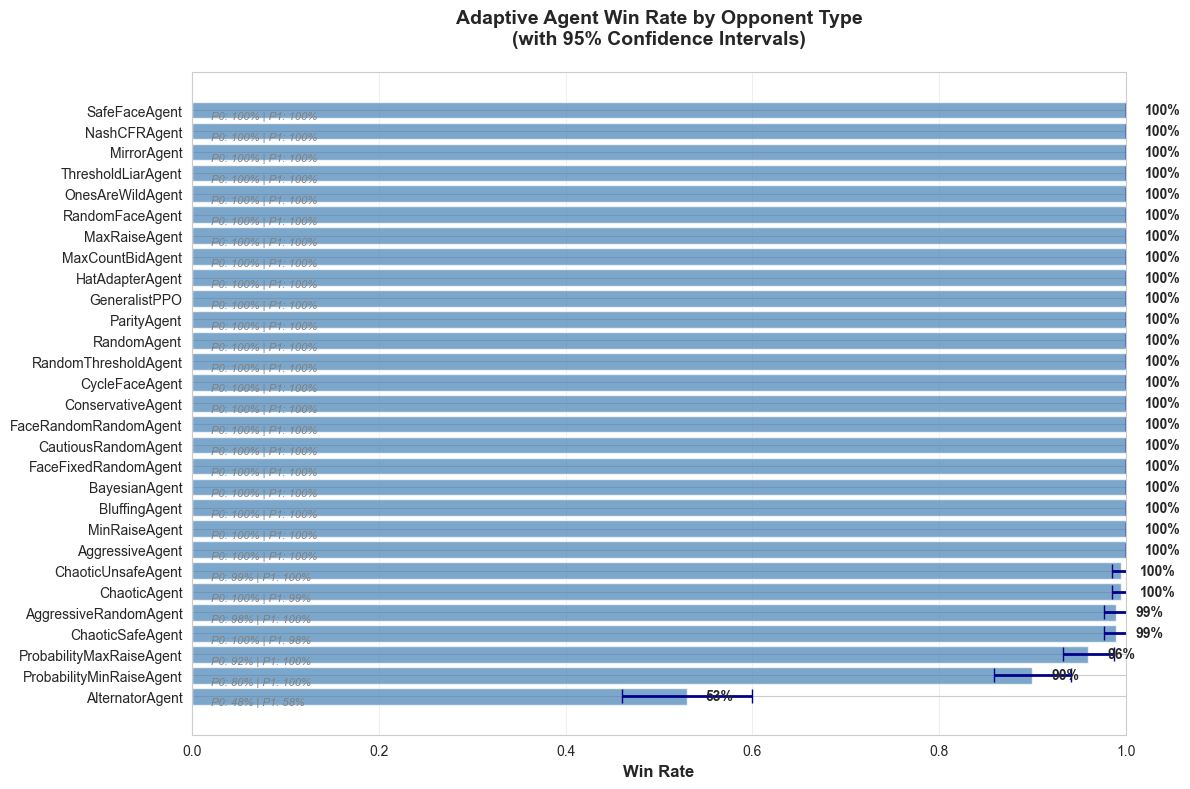

✓ Win rate chart saved as 'adaptive_agent_win_rates.png'


In [7]:
# Sort by win rate for better visualization
df_plot = df_win_rates.sort_values('Win Rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

# Create bar chart with error bars
y_pos = np.arange(len(df_plot))
bars = ax.barh(y_pos, df_plot['Win Rate'].values, 
                xerr=df_plot['CI'].values,
                capsize=5, alpha=0.7, color='steelblue', 
                error_kw={'linewidth': 2, 'ecolor': 'darkblue'})

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['Opponent'].values)
ax.set_xlabel('Win Rate', fontsize=12, fontweight='bold')
ax.set_title('Adaptive Agent Win Rate by Opponent Type\n(with 95% Confidence Intervals)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

# Add percentage labels and player position info
for i, (idx, row) in enumerate(df_plot.iterrows()):
    wr_pct = f"{row['Win Rate']:.0%}"
    p0_pct = f"{row['P0 WR']:.0%}"
    p1_pct = f"{row['P1 WR']:.0%}"
    
    # Win rate label
    ax.text(row['Win Rate'] + 0.02, i, f"{wr_pct}", 
            va='center', fontweight='bold', fontsize=10)
    
    # Player position labels (smaller)
    ax.text(0.02, i - 0.3, f"P0: {p0_pct} | P1: {p1_pct}", 
            va='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig('adaptive_agent_win_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Win rate chart saved as 'adaptive_agent_win_rates.png'")

## 8. Analyze Steps Until Adversary Identification

In [9]:
print("="*60)
print("ADVERSARY IDENTIFICATION SPEED")
print("="*60)

# Overall statistics
steps_data = df_results['steps_to_identification'].values
print(f"\nOverall Statistics:")
print(f"  Mean steps to ID: {np.mean(steps_data):.2f}")
print(f"  Median steps to ID: {np.median(steps_data):.2f}")
print(f"  Std Dev: {np.std(steps_data):.2f}")
print(f"  Min: {np.min(steps_data):.0f}, Max: {np.max(steps_data):.0f}")

# By opponent
print(f"\n" + "="*60)
print("STEPS TO IDENTIFICATION BY OPPONENT")
print("="*60)

id_speed_data = []
for opp in sorted(df_results['opponent'].unique()):
    opp_steps = df_results[df_results['opponent'] == opp]['steps_to_identification'].values
    id_speed_data.append({
        'Opponent': opp,
        'Mean Steps': np.mean(opp_steps),
        'Median Steps': np.median(opp_steps),
        'Std Dev': np.std(opp_steps),
        'Min': np.min(opp_steps),
        'Max': np.max(opp_steps),
    })

df_id_speed = pd.DataFrame(id_speed_data)
df_id_speed = df_id_speed.sort_values('Mean Steps')
print(df_id_speed.to_string(index=False))

ADVERSARY IDENTIFICATION SPEED

Overall Statistics:
  Mean steps to ID: 7.62
  Median steps to ID: 8.00
  Std Dev: 1.79
  Min: 3, Max: 10

STEPS TO IDENTIFICATION BY OPPONENT
                Opponent  Mean Steps  Median Steps  Std Dev  Min  Max
ProbabilityMinRaiseAgent       4.500           4.5 0.500000    4    5
ProbabilityMaxRaiseAgent       4.500           4.5 0.500000    4    5
         AlternatorAgent       5.500           5.5 0.500000    5    6
           BayesianAgent       6.000           6.0 1.000000    5    7
       ConservativeAgent       6.000           6.0 1.000000    5    7
             ParityAgent       6.000           6.0 1.000000    5    7
      ThresholdLiarAgent       7.000           7.0 1.000000    6    8
      ChaoticUnsafeAgent       7.180           7.0 1.502531    4   10
            ChaoticAgent       7.210           7.0 1.541395    3   10
        ChaoticSafeAgent       7.295           7.0 1.548540    4   10
         AggressiveAgent       7.500           7.5 0.50